# 1) About

## a. Purpose:

This notebook performs the initial exploration of AMLSim dataset and will provide an empirical foundation for the modeling phase. Objective is to:

Understand the structure & content of the dataset (accounts, transactions, alerts)

Identify key columns

Assess data quality & completeness

Explore distributions of key columns (e.g. transaction amount)

Investigate early signals consistent with structuring behavior

## b. Business Context:

In Anti-Money Laundering (AML), structuring refers to the practice of splitting large transactions into smaller amounts to avoid regulatory reporting thresholds.

Detection of structuring relies on identifying behavioral patterns over time rather than isolated transactions.

Before designing any predictive model, it is critical to validate:

Whether near-threshold activity exists
How client behavior evolves over time
Whether suspicious patterns are observable in raw data
This notebook focuses solely on that validation.

## c. Analytical Philosophy:

This NB will help:

Form hypotheses about behavioral risk signals

Identify potential modeling variables (features)

Understand time granularity

Detect anomalies and skewness

Reveal structural patterns in client activity

## d. Dataset

AMLsim data simulates banking transactions and embedded suspicious activity patterns

accounts.csv, transactions.csv, alerts.csv
## e. Outcome of This Notebook

Understand dataset structure and distributions

Identify plausible structuring thresholds

Detect behavioral variation across clients

Establish foundations for feature design

# 2) Imports & Definitions

In [191]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.ticker import FuncFormatter

import networkx as nx

from typing import Dict, List, Optional, Tuple

pio.templates.default = "plotly_white"
pd.set_option("display.max_columns", None)
pd.set_option('display.expand_frame_repr', False)


In [190]:
data_path = Path("../data/raw")

df_acc = pd.read_csv(data_path/ "accounts.csv") 
df_trx = pd.read_csv(data_path/ "transactions.csv") 
df_alerts = pd.read_csv(data_path/ "alerts.csv") 


# 3) Data Inspection

Check column structure and identify *client level* keys.

In [132]:
print(df_acc.head(), df_acc.shape)
print()
print(df_trx.head(), df_trx.shape)
print()
print(df_alerts.head(), df_alerts.shape)


   ACCOUNT_ID CUSTOMER_ID  INIT_BALANCE COUNTRY ACCOUNT_TYPE  IS_FRAUD  TX_BEHAVIOR_ID
0           0         C_0        184.44      US            I     False               1
1           1         C_1        175.80      US            I     False               1
2           2         C_2        142.06      US            I     False               1
3           3         C_3        125.89      US            I     False               1
4           4         C_4        151.13      US            I     False               1 (10000, 7)

   TX_ID  SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID   TX_TYPE  TX_AMOUNT  TIMESTAMP  IS_FRAUD  ALERT_ID
0      1               6456                 9069  TRANSFER     465.05          0     False        -1
1      2               7516                 9543  TRANSFER     564.64          0     False        -1
2      3               2445                 9356  TRANSFER     598.94          0     False        -1
3      4               2576                 4617  TRANSFER    

## 2.a Deeper Look - Accounts

Data Quality:

- Data types

- Null/ missing value inspection

- Formatting


Data Model:

- What is trx behavior id?

- How many customers, how many accounts? (client id - account id -> is it one to many or one to many mapping?)

- Account types?

- Can one client have both fraud and nonfraud?


## Findings:

- No missing values.

- All clients are based in US & Individuals.

- Between client_id and account_id there is 1-1 mapping, following this convention -> client_id = c_{account_id}. Therefore account_id can be used as the primary key.

- A client can be only either fraudulent or non-fraudulent.

In [ ]:
print("\n1. General Distribution:")

print(df_acc.info())
print()
print(f"   Number of Distinct ClientIds: {df_acc['CUSTOMER_ID'].nunique()}")
print(f"   Number of Distinct AccountIds: {df_acc['ACCOUNT_ID'].nunique()}")
print(f"   Number of Distinct Countries: {df_acc['COUNTRY'].nunique()}, Countries:{df_acc['COUNTRY'].unique()}")
print(f"   Number of Distinct ACCOUNT_TYPEs: {df_acc['ACCOUNT_TYPE'].nunique()}, Types:{df_acc['ACCOUNT_TYPE'].unique()}")
print(f"   Number of Distinct TX_BEHAVIOR_IDs: {df_acc['TX_BEHAVIOR_ID'].nunique()}, TX_BEHAVIOR_IDs:{df_acc['TX_BEHAVIOR_ID'].unique()}")
print(f"   Number of Distinct IS_FRAUD: {df_acc['IS_FRAUD'].nunique()}, IS_FRAUD:{df_acc['IS_FRAUD'].unique()}")
# print("\n5. FRAUD DISTRIBUTION:"

print("\n2. ClientId - AccountId Mapping: ")

df_acc.groupby(['CUSTOMER_ID', 'ACCOUNT_ID']).size().reset_index(name='Count').sort_values(by='Count', ascending=False).head(10)


print('Does all of client_ids == c_{account_ids}?')
(df_acc["CUSTOMER_ID"] == "C_" + df_acc["ACCOUNT_ID"].astype(str)).all()




print('\n3. Fraud Inspection: Can a client be both fraud and non-fraud?')

df_acc.groupby(
    ['CUSTOMER_ID', 'ACCOUNT_ID']
)['IS_FRAUD'].nunique().reset_index(name='UniqueValues').where(lambda x: x['UniqueValues'] > 1).query("UniqueValues > 1")



1. General Distribution:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ACCOUNT_ID      10000 non-null  int64  
 1   CUSTOMER_ID     10000 non-null  str    
 2   INIT_BALANCE    10000 non-null  float64
 3   COUNTRY         10000 non-null  str    
 4   ACCOUNT_TYPE    10000 non-null  str    
 5   IS_FRAUD        10000 non-null  bool   
 6   TX_BEHAVIOR_ID  10000 non-null  int64  
dtypes: bool(1), float64(1), int64(2), str(3)
memory usage: 478.6 KB
None

   Number of Distinct ClientIds: 10000
   Number of Distinct AccountIds: 10000
   Number of Distinct Countries: 1, Countries:<StringArray>
['US']
Length: 1, dtype: str
   Number of Distinct ACCOUNT_TYPEs: 1, Types:<StringArray>
['I']
Length: 1, dtype: str
   Number of Distinct TX_BEHAVIOR_IDs: 5, TX_BEHAVIOR_IDs:[1 2 3 4 5]
   Number of Distinct IS_FRAUD: 2, IS_FRAUD:[False  True]

2. ClientId -

,CUSTOMER_ID,ACCOUNT_ID,UniqueValues


## 2.b Deeper Look - Transactions

Data Quality:

- Data types

- Null/ missing value inspection

- Formatting


Data Model:

- Is transactionid unique?

- Can a transaction be both fradulent and non-fradulent? 

- Are all receivers and senders our clients?



## Findings:

- TrxId is unique 

- A trx-id is either fraudulent or non-fraudulent

- All senders and receivers are our clients

- Alerts are transaction-level (but my model will be client-level.)

- Most trx are between 100-400

In [ ]:
print('\n1. General Distribution:')

print(df_trx.info())
print()
print(f"   Number of Distinct TransactionIds: {df_trx['TX_ID'].nunique()}")
print(f"   Number of Distinct ReceviverAccountIds: {df_trx['RECEIVER_ACCOUNT_ID'].nunique()}, Number of Distinct SenderAccountIds: {df_trx['SENDER_ACCOUNT_ID'].nunique()}")
print(f"   Number of Distinct TransactionTypes: {df_trx['TX_TYPE'].nunique()}, Types:{df_trx['TX_TYPE'].unique()}")
print(f"  Number of Distinct Fraud Status: {df_trx['IS_FRAUD'].nunique()}, Channels:{df_trx['IS_FRAUD'].unique()}")
print(f"  Number of Distinct AlertIds: {df_trx['ALERT_ID'].nunique()},  AlertIds:{sorted(df_trx['ALERT_ID'].unique())}")
print(f"  Number of Distinct TimeStamps: {df_trx['TIMESTAMP'].nunique()}, TimeStamps:{df_trx['TIMESTAMP'].unique()}")

print('\n Is TransactionId the Unique Key?:')
print(f"   Number of Distinct TransactionIds: {df_trx['TX_ID'].nunique()}, Total Rows: {len(df_trx)}")



print('\n2. Fraud Inspection')

print('\n Number of Fraud and Non-Fraud Transactions:')

print(df_trx['IS_FRAUD'].value_counts())


('print \n Can a transaction be both fraud and non-fraud?')

df_trx.groupby(
    ['TX_ID']
)['IS_FRAUD'].nunique().reset_index(name='UniqueValues').where(lambda x: x['UniqueValues'] > 1).query("UniqueValues > 1")


print('\n3. Senders/Receivers')

print(f"   Number of Distinct ReceviverAccountIds: {df_trx['RECEIVER_ACCOUNT_ID'].nunique()}, Number of Distinct SenderAccountIds: {df_trx['SENDER_ACCOUNT_ID'].nunique()}")



print(f"   Are all senders and receivers in the accounts dataset?")

sender_accounts = set(df_trx['SENDER_ACCOUNT_ID'].unique())
receiver_accounts = set(df_trx['RECEIVER_ACCOUNT_ID'].unique())
account_ids = set(df_acc['ACCOUNT_ID'].unique())

missing_senders = sender_accounts - account_ids
missing_receivers = receiver_accounts - account_ids

print(f"   Missing Sender Accounts: {missing_senders}")
print(f"   Missing Receiver Accounts: {missing_receivers}")


print(f"   Transaction Count per Sender and Receiver:")

df_trx.groupby(['SENDER_ACCOUNT_ID', 'RECEIVER_ACCOUNT_ID']).size().reset_index(name='TransactionCount').sort_values(by='TransactionCount', ascending=False).head(10)




1. General Distribution:
<class 'pandas.DataFrame'>
RangeIndex: 1323234 entries, 0 to 1323233
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   TX_ID                1323234 non-null  int64  
 1   SENDER_ACCOUNT_ID    1323234 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  1323234 non-null  int64  
 3   TX_TYPE              1323234 non-null  str    
 4   TX_AMOUNT            1323234 non-null  float64
 5   TIMESTAMP            1323234 non-null  int64  
 6   IS_FRAUD             1323234 non-null  bool   
 7   ALERT_ID             1323234 non-null  int64  
dtypes: bool(1), float64(1), int64(5), str(1)
memory usage: 71.9 MB
None

   Number of Distinct TransactionIds: 1323234
   Number of Distinct ReceviverAccountIds: 9926, Number of Distinct SenderAccountIds: 9999
   Number of Distinct TransactionTypes: 1, Types:<StringArray>
['TRANSFER']
Length: 1, dtype: str
  Number of Distinct Fraud Status: 2, Channe


1. General Distribution:
<class 'pandas.DataFrame'>
RangeIndex: 1323234 entries, 0 to 1323233
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   TX_ID                1323234 non-null  int64  
 1   SENDER_ACCOUNT_ID    1323234 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  1323234 non-null  int64  
 3   TX_TYPE              1323234 non-null  str    
 4   TX_AMOUNT            1323234 non-null  float64
 5   TIMESTAMP            1323234 non-null  int64  
 6   IS_FRAUD             1323234 non-null  bool   
 7   ALERT_ID             1323234 non-null  int64  
dtypes: bool(1), float64(1), int64(5), str(1)
memory usage: 71.9 MB
None

   Number of Distinct TransactionIds: 1323234
   Number of Distinct ReceviverAccountIds: 9926, Number of Distinct SenderAccountIds: 9999
   Number of Distinct TransactionTypes: 1, Types:<StringArray>
['TRANSFER']
Length: 1, dtype: str
  Number of Distinct Fraud Status: 2, Channe

,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TransactionCount
5138,1505,9499,181
19487,4586,1600,181
9354,2532,5272,181
31678,6524,8794,180
48112,8494,9224,180
48093,8476,5196,180
48095,8478,7131,180
48096,8479,4480,180
48099,8482,6793,180
48101,8483,9026,180


## Transaction Network Structure

## Findings:

Incoming transaction counts > outgoing transactions counts (e.g. max incoming: 4843, max outgoing: 963)

In [137]:
# Transaction Network Structure

outgoing = df_trx.groupby("SENDER_ACCOUNT_ID").size().reset_index(name='OutgoingCount').sort_values(by='OutgoingCount', ascending=False).head(10)

incoming = df_trx.groupby("RECEIVER_ACCOUNT_ID").size().reset_index(name='IncomingCount').sort_values(by='IncomingCount', ascending=False).head(10)

outgoing.head(10), incoming.head(10)


(      SENDER_ACCOUNT_ID  OutgoingCount
 9798               9799            963
 9796               9797            962
 9784               9785            922
 9789               9790            921
 9791               9792            921
 9792               9793            921
 9783               9784            921
 9797               9798            920
 9795               9796            920
 9794               9795            920,
       RECEIVER_ACCOUNT_ID  IncomingCount
 9908                 9982           4843
 9919                 9993           3948
 9897                 9971           3420
 9909                 9983           2850
 9924                 9998           2767
 9920                 9994           2730
 9925                 9999           2699
 9809                 9883           2667
 9876                 9950           2610
 9906                 9980           2545)

In [ ]:
df_trx.head()


,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,IS_FRAUD,ALERT_ID,log_tx_amount
0,1,6456,9069,TRANSFER,465.05,0,False,-1,6.144293
1,2,7516,9543,TRANSFER,564.64,0,False,-1,6.337958
2,3,2445,9356,TRANSFER,598.94,0,False,-1,6.396830
3,4,2576,4617,TRANSFER,466.07,0,False,-1,6.146479
4,5,3524,1773,TRANSFER,405.63,0,False,-1,6.007904


In [ ]:
log_amount


0          2.668433
1          2.752540
2          2.778108
3          2.669382
4          2.609199
             ...   
1323229    2.056829
1323230    2.663362
1323231    2.671728
1323232    2.750786
1323233    2.619688
Name: TX_AMOUNT, Length: 1323234, dtype: float64

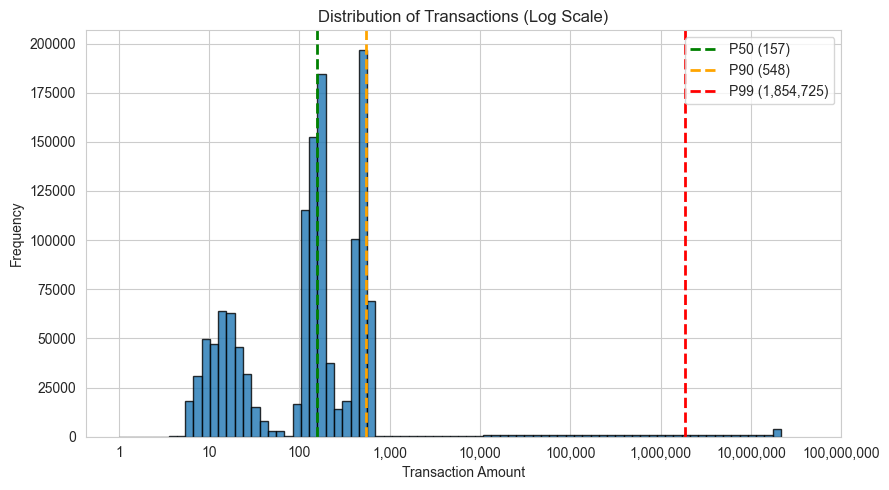

In [193]:
# Log transform
log_amount = np.log10(df_trx["TX_AMOUNT"] + 1)

# Create figure
plt.figure(figsize=(9,5))

# Histogram
plt.hist(log_amount, bins=80, edgecolor="black", alpha=0.8)

# -------- Automatic tick generation --------
max_log = int(np.ceil(log_amount.max()))
ticks = np.arange(0, max_log + 1)

# Clean power-of-10 labels
tick_labels = [f"{int(10**t):,}" for t in ticks]

plt.xticks(ticks, tick_labels)

# -------- Percentile calculations --------
p50 = np.percentile(log_amount, 50)
p90 = np.percentile(log_amount, 90)
p99 = np.percentile(log_amount, 99)

# Convert percentiles back to real values
p50_real = 10**p50 - 1
p90_real = 10**p90 - 1
p99_real = 10**p99 - 1

# Plot percentile lines
plt.axvline(p50, color="green", linestyle="--", linewidth=2,
            label=f"P50 ({p50_real:,.0f})")

plt.axvline(p90, color="orange", linestyle="--", linewidth=2,
            label=f"P90 ({p90_real:,.0f})")

plt.axvline(p99, color="red", linestyle="--", linewidth=2,
            label=f"P99 ({p99_real:,.0f})")

# Labels
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transactions (Log Scale)")

plt.legend()
plt.tight_layout()

plt.show()


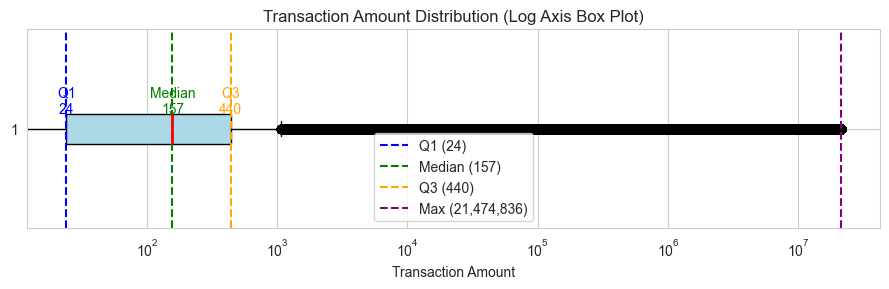

In [205]:
import numpy as np
import matplotlib.pyplot as plt

amounts = df_trx["TX_AMOUNT"]

# Quartiles
q1 = np.percentile(amounts, 25)
median = np.percentile(amounts, 50)
q3 = np.percentile(amounts, 75)
max_amt = np.max(amounts)

plt.figure(figsize=(9,3))

plt.boxplot(
    amounts,
    vert=False,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue"),
    medianprops=dict(color="red", linewidth=2)
)

# Log axis
plt.xscale("log")

# Quartile lines
plt.axvline(q1, linestyle="--", color="blue", label=f"Q1 ({q1:,.0f})")
plt.axvline(median, linestyle="--", color="green", label=f"Median ({median:,.0f})")
plt.axvline(q3, linestyle="--", color="orange", label=f"Q3 ({q3:,.0f})")
plt.axvline(max_amt, linestyle="--", color="purple", label=f"Max ({max_amt:,.0f})")

# Annotations
plt.text(q1, 1.08, f"Q1\n{q1:,.0f}", ha="center", color="blue")
plt.text(median, 1.08, f"Median\n{median:,.0f}", ha="center", color="green")
plt.text(q3, 1.08, f"Q3\n{q3:,.0f}", ha="center", color="orange")

plt.xlabel("Transaction Amount")
plt.title("Transaction Amount Distribution (Log Axis Box Plot)")

plt.legend()
plt.tight_layout()
plt.show()


#

## 2.c Deeper Look - Alerts

- Accounts data has demonstrated that a client could be either fraudulent or non-fraudulent. What is the 




In [ ]:
print('\n1. General Distribution:')

print(df_alerts.info())

print(f"   Number of Distinct AlertIds: {df_alerts['ALERT_ID'].nunique()}")     
print(f"   Number of Distinct AlertIds: {df_alerts['ALERT_ID'].nunique()}, AlertIds:{df_alerts['ALERT_ID'].unique()}")
print(f"   Number of Distinct AlertTypes: {df_alerts['ALERT_TYPE'].nunique()}, Types:{df_alerts['ALERT_TYPE'].unique()}")
print(f"   Number of Distinct TimeStamps: {df_alerts['TIMESTAMP'].nunique()}, TimeStamps:{df_alerts['TIMESTAMP'].unique()}")




1. General Distribution:
<class 'pandas.DataFrame'>
RangeIndex: 1719 entries, 0 to 1718
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ALERT_ID             1719 non-null   int64  
 1   ALERT_TYPE           1719 non-null   str    
 2   IS_FRAUD             1719 non-null   bool   
 3   TX_ID                1719 non-null   int64  
 4   SENDER_ACCOUNT_ID    1719 non-null   int64  
 5   RECEIVER_ACCOUNT_ID  1719 non-null   int64  
 6   TX_TYPE              1719 non-null   str    
 7   TX_AMOUNT            1719 non-null   float64
 8   TIMESTAMP            1719 non-null   int64  
dtypes: bool(1), float64(1), int64(5), str(2)
memory usage: 109.2 KB
None
   Number of Distinct AlertIds: 391
   Number of Distinct AlertIds: 391, AlertIds:[193 377 189 130 183 267 176 170   8 202 260 346 115 374 317  41 179  39
  61  32  14 323 174 166 356 100 242  88 363  68 138 145 330 302 387 351
  79 322 134 326 342  66 33

In [ ]:
# top senders

print(df_trx.groupby('SENDER_ACCOUNT_ID').size().sort_values(ascending=False).reset_index(name='count').head(10), '\n', df_trx.groupby('RECEIVER_ACCOUNT_ID').size().sort_values(ascending=False).reset_index(name='count').head(10))


## Transactions - Network Overview

In [ ]:
df_trx.head()
